### Data Preprocessing, add tatical features.

In [1]:
import pandas as pd
from src.data_pipeline.feature_engineering import main_data_pipeline
import os
from src.data_pipeline.clean import main_clean_pipeline

BASE_DIR = "./data_match61"

# ------------------------------------------
tournament_csv_path = os.path.join(BASE_DIR, "tournament.csv")
match_csv_path = os.path.join(BASE_DIR, "match.csv")
set_csv_path = os.path.join(BASE_DIR, "set.csv")
rally_csv_path = os.path.join(BASE_DIR, "rally.csv")
shot_csv_path = os.path.join(BASE_DIR, "shot.csv")

# ------------------------------------------
# Keep or remove for columns
# ------------------------------------------
tournament_cols_to_keep = ['tournament_id', 'level']
match_cols_to_keep = ['match_id', 'event','tournament_id','duration','set_count']
shot_cols_to_remove = ['time', 'start_frame_num', 'end_frame_num', 'set_num', 'current_win_score', 
                       'current_lose_score', 'lose_reason', 'score_team']
rally_cols_to_remove = ['start_frame', 'end_frame', 'comment', 'rally_video_check', 'score_reason','shot_count']


# Tournament
tournament_data = pd.read_csv(tournament_csv_path)
tournament_cols_to_remove = tournament_data.columns.difference(tournament_cols_to_keep).tolist()
tournament_data = tournament_data.drop(columns=tournament_cols_to_remove, errors='ignore')
tournament_data['level'] = tournament_data['level'].astype(str).str.replace('Super ', '', case=False).str.strip()

# Match
match_data = pd.read_csv(match_csv_path)
match_data['match_id'] = pd.to_numeric(match_data['match_id'], errors='coerce').fillna(0).astype('Int64')
match_data['event'] = pd.to_numeric(match_data['event'], errors='coerce').fillna(0).astype(int)
match_cols_to_remove = match_data.columns.difference(match_cols_to_keep).tolist()
match_data = match_data.drop(columns=match_cols_to_remove, errors='ignore')

# Set
set_data = pd.read_csv(set_csv_path)
set_data['match_id'] = pd.to_numeric(set_data['match_id'], errors='coerce').astype('Int64')

# Rally
rally_data = pd.read_csv(rally_csv_path)
rally_data = rally_data.drop(columns=rally_cols_to_remove, errors='ignore')

# Shot
shot_data = pd.read_csv(shot_csv_path)
shot_data = shot_data.drop(columns=shot_cols_to_remove, errors='ignore')
shot_data = main_clean_pipeline(shot_data)

# Merge
df_match_rally_shot = pd.merge(
        left=shot_data,
        right=rally_data,
        on='rally_id', 
        how='left'     
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=set_data,
        on='set_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=match_data,
        on='match_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )

full_df = main_data_pipeline(df_match_rally_shot)

print("(rows, columns):", full_df.shape)
print("Effective feature：\n", full_df.columns.tolist())
display(full_df.head(10))
OUTPUT_FILE = os.path.join(BASE_DIR, "df_cleaned_with_feature.csv")
full_df.to_csv(OUTPUT_FILE, index=False)


[Start Data Clean]...

--- Data Clean Result ---
Origin 58359 rows
Remove 519 rows (coordinate outlier/unclassified/hit_height=0/Error Case)
Final 57840 rows
--- remove result ---
Origin 57840 rows。
363 rally of Exception
Remove 3699 rows。
Final 54141 rows。

[Data Clean Finished]

--- Clean return height ---

--- 球種映射完成 ---
最終分類結果:
ball_type
net shot         11266
lift             11074
smash             9363
drive             7894
push              4105
short serve       3883
drop              3398
clear             2542
long serve         595
uncategorized       21
Name: count, dtype: int64

--- 1-16 blocks result---
Hitting_Zone
8     16388
4      7211
6      6831
9      6809
5      5570
3      5513
7      4230
2       956
1       570
13       54
12        4
14        4
11        1
Name: count, dtype: int64

--- Partner Angle Bin result ---
Angle_Bin
0    13690
1     6450
2     7449
3    11748
4    14804
Name: count, dtype: int64

--- add center coverage and formation ---

--- Ball

,shot_id,rally_id,shot_num,player,ball_type,backhand,player_A_x,player_A_y,player_B_x,player_B_y,...,shots_to_end,is_defense_failure,player_formation,next_rally_id,next_winner_mid_cover,next_loser_mid_cover,is_reaction_cover,match_Winner_AAI,match_Loser_AAI,ball_up_down
0,1,1,1,5.0,short serve,1,28.639847,94.300792,31.751217,113.677100,...,6,False,Attack,1.0,True,True,True,NaN,0.064047,0
1,2,1,2,7.0,push,1,34.001378,88.407620,32.780770,114.213560,...,5,False,Attack,1.0,True,True,True,0.342563,NaN,0
2,3,1,3,6.0,lift,1,36.690095,87.092290,36.825915,111.609023,...,4,False,Attack,1.0,True,True,True,NaN,0.013322,1
3,4,1,4,8.0,smash,0,24.759652,109.455966,48.761037,122.480082,...,3,False,Attack,1.0,True,True,True,0.597411,NaN,2
4,5,1,5,6.0,drive,1,24.160234,111.525887,46.772711,118.061801,...,2,True,Defense,1.0,False,True,False,NaN,0.769209,1
5,6,1,6,7.0,push,0,24.894581,115.227577,46.021033,119.147169,...,1,False,Attack,1.0,False,True,True,0.313007,NaN,2
6,7,1,7,6.0,drive,1,23.988683,114.688232,45.905338,119.146436,...,0,False,Defense,2.0,True,True,NaN,NaN,0.617746,0
7,8,2,1,8.0,short serve,1,30.606006,111.047223,41.950872,93.466893,...,13,False,Attack,2.0,True,True,True,0.372578,NaN,0
8,9,2,2,6.0,net shot,0,30.711310,108.468965,40.302603,86.235682,...,12,False,Attack,2.0,True,True,True,NaN,0.204983,0
9,10,2,3,8.0,lift,0,30.268870,112.088710,30.020094,83.111510,...,11,False,Defense,2.0,True,True,True,0.249663,NaN,1


In [2]:
import pandas as pd
import os
BASE_DIR = "./data_match61"

full_df_path = os.path.join(BASE_DIR, "df_cleaned_with_feature.csv")
full_df = pd.read_csv(full_df_path)

/tmp/ipykernel_1816193/2325330784.py:6: DtypeWarning: Columns (0: level, 1: next_winner_mid_cover, 2: next_loser_mid_cover) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv(full_df_path)


findfont: Font family ['Microsoft JhengHei'] not found. Falling back to DejaVu Sans.


Successfully loaded data, initial number of events: 54141
Filtered out Angle=-404.0 and invalid rows, final number of valid shots: 40251

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Defensive Shot    0.81
Offensive Shot    0.19
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Zone
Backcourt    0.27
Forecourt    0.10
Midcourt     0.62
Name: Count, dtype: float64
--------------------



/home/chien/Desktop/DShuttleNet/src/analysis/general_analyze.py:147: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


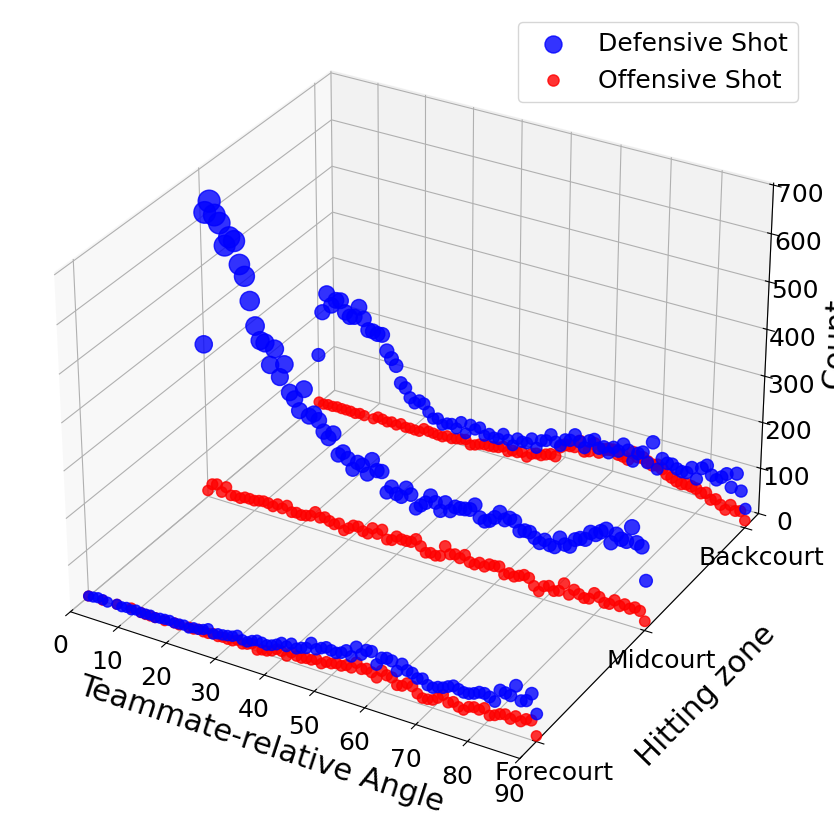

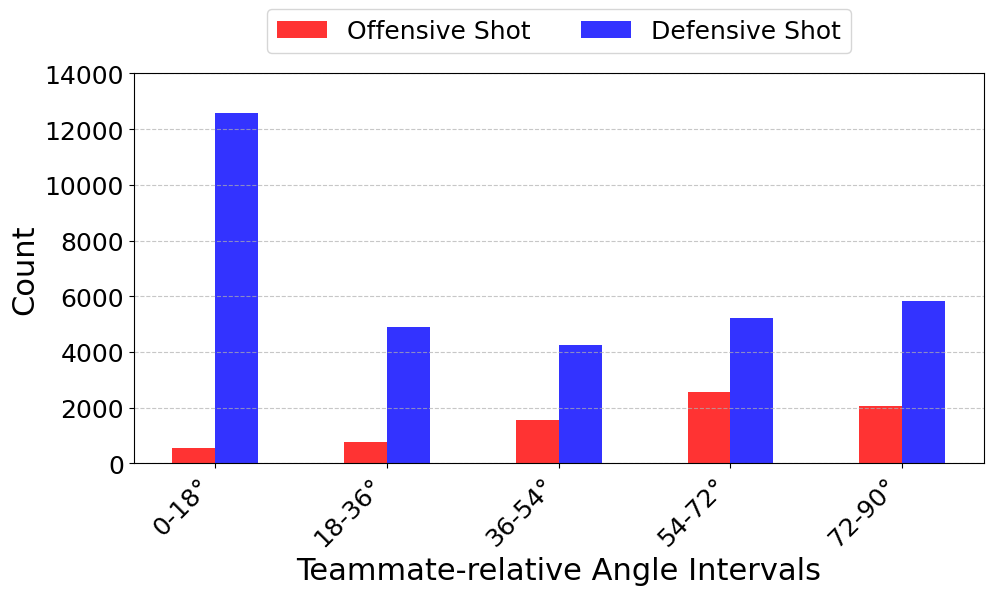

Successfully loaded data, original event count: 54141
Filtered Angle=-404.0 and invalid rows, final valid shot events: 49579
Filtered BallType: ['long serve', 'short serve', 'uncategorized']

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Downward Shot    0.38
Flat Shot        0.28
Upward Shot      0.35
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Series([], Name: Count, dtype: float64)
--------------------



/home/chien/Desktop/DShuttleNet/src/analysis/general_analyze.py:348: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


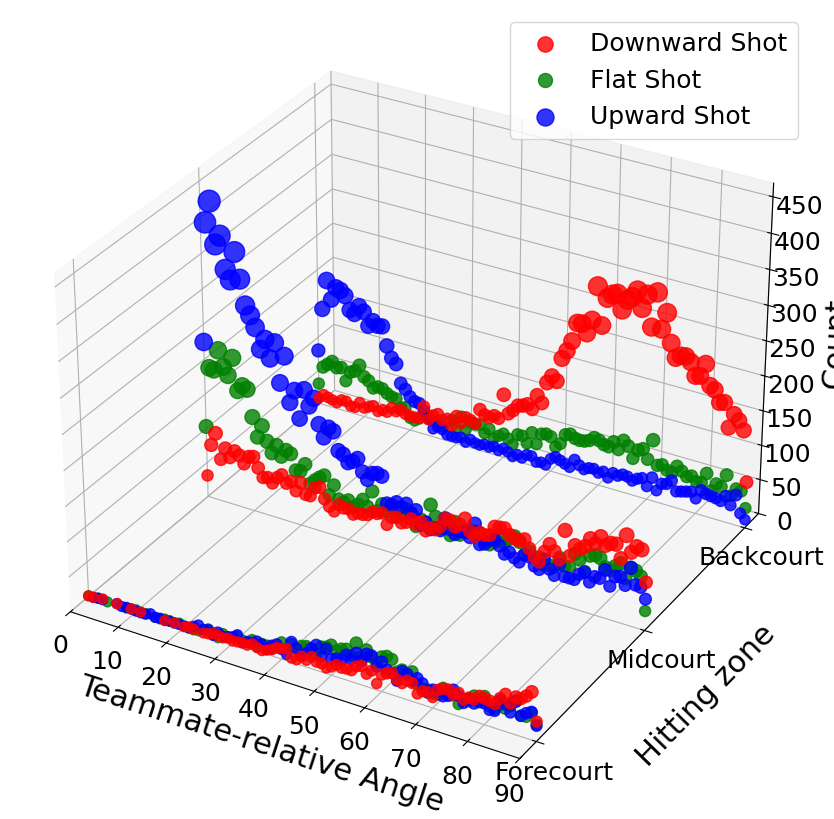

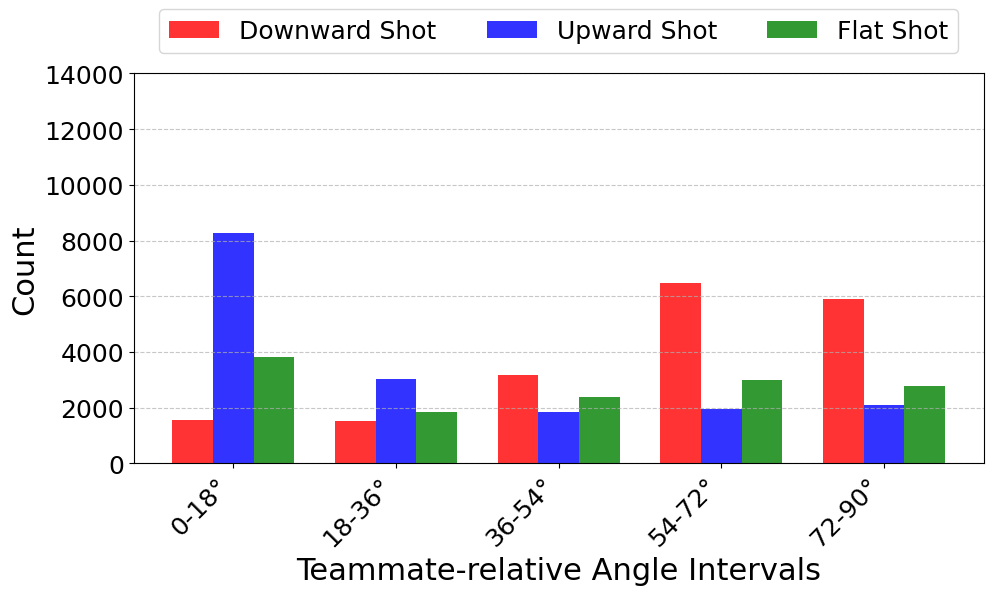

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
from src.analysis.general_analyze import plot_badminton_shot_analysis, plot_badminton_up_down_analysis, analyze_badminton_rally_stats,  analyze_badminton_shot_distribution


plot_badminton_shot_analysis(full_df)
plot_badminton_up_down_analysis(full_df)

In [5]:
analyze_badminton_rally_stats(full_df)
analyze_badminton_shot_distribution(full_df)

=== Badminton Rally/Shot Statistics ===
event_name  total_rallies  total_shots  average_shots_per_rally  max_shots  min_shots
        MD           1841        15344                     8.33         60          1
        WD           1843        31737                    17.22        186          1
        XD            799         7060                     8.84         60          1
----------------------------------------
Total Rallies: 4483
Total Shots: 54141
Average Shots per Rally: 12.08

--- Final Analysis Report [Count (Percentage)] ---
                        MD             WD             XD           Total
Drop           534 (3.48%)   2632 (8.29%)    232 (3.29%)    3398 (6.28%)
Long Serve     237 (1.54%)    222 (0.70%)    136 (1.93%)     595 (1.10%)
Short Serve  1601 (10.43%)   1620 (5.10%)    662 (9.38%)    3883 (7.17%)
Drive        2950 (19.23%)  3803 (11.98%)  1141 (16.16%)   7894 (14.58%)
Lift         2171 (14.15%)  7984 (25.16%)   919 (13.02%)  11074 (20.45%)
Push/Rush    15

,MD,WD,XD,Total
Drop,534 (3.48%),2632 (8.29%),232 (3.29%),3398 (6.28%)
Long Serve,237 (1.54%),222 (0.70%),136 (1.93%),595 (1.10%)
Short Serve,1601 (10.43%),1620 (5.10%),662 (9.38%),3883 (7.17%)
Drive,2950 (19.23%),3803 (11.98%),1141 (16.16%),7894 (14.58%)
Lift,2171 (14.15%),7984 (25.16%),919 (13.02%),11074 (20.45%)
Push/Rush,1550 (10.10%),1929 (6.08%),626 (8.87%),4105 (7.58%)
Smash,2297 (14.97%),6165 (19.43%),901 (12.76%),9363 (17.29%)
Net Shot,3836 (25.00%),5111 (16.10%),2319 (32.85%),11266 (20.81%)
Clear,163 (1.06%),2257 (7.11%),122 (1.73%),2542 (4.70%)
Total,15344,31737,7060,54141


分析中: 共 26351 筆 Attack 陣型下的擊球數據。

--- Reaction-Cover ---
                   total_attempts  total_failures  failure_rate  success_rate
is_reaction_cover                                                            
True                        22814            2270      9.950031     90.049969
False                        1291             167     12.935709     87.064291

[卡方檢定與效應量]
Chi-square: 11.66
p-value: 0.00064

--- (Chi-Square Test) ---
p-value: 0.00064


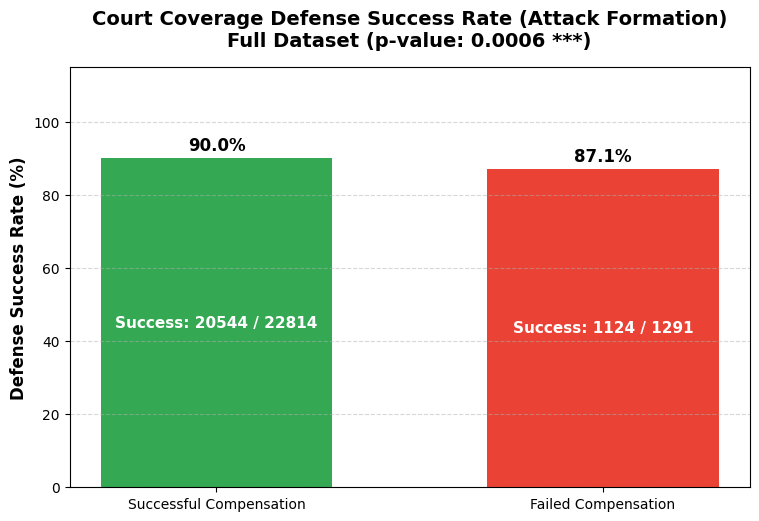

In [17]:
from src.analysis.cce_analysis import global_cce_analysis
global_cce_analysis(full_df, event_type=None
                         , selected_type=['對手落地致勝','未過網','掛網','出界'], shot_to_end=[1,2,3])

In [18]:
from src.analysis.tlai_analysis import analyze_defense_aai
analyze_defense_aai(full_df, threat_shot_types = ['殺球', '切球'])

ModuleNotFoundError: No module named 'statsmodels'

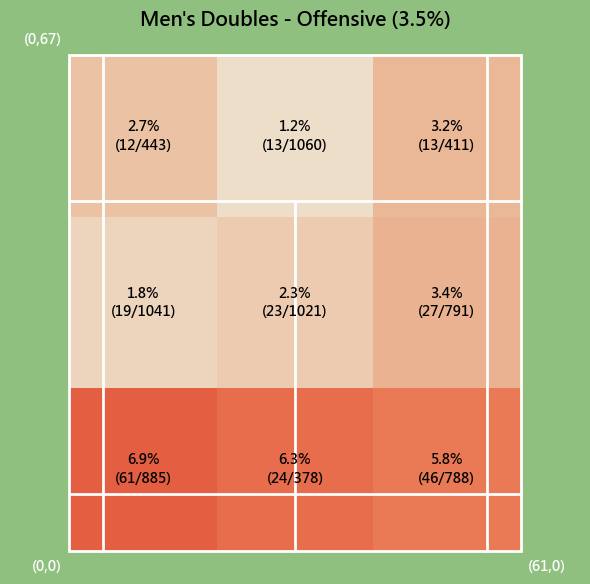

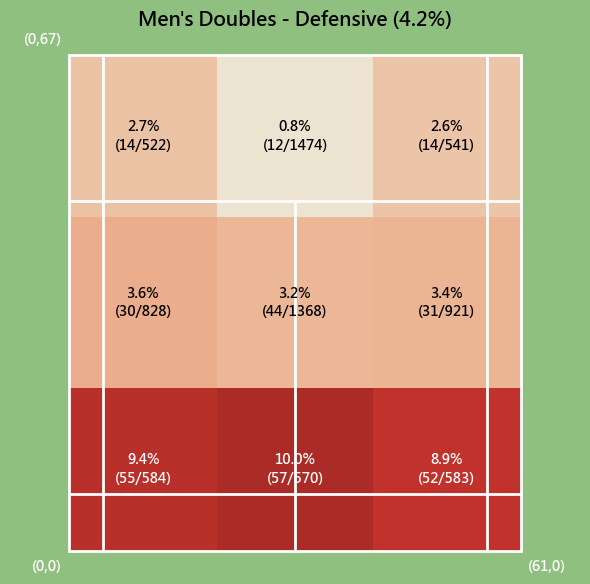

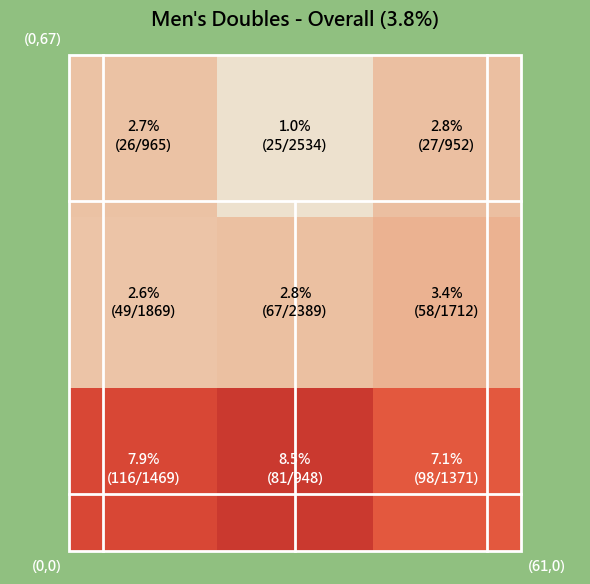

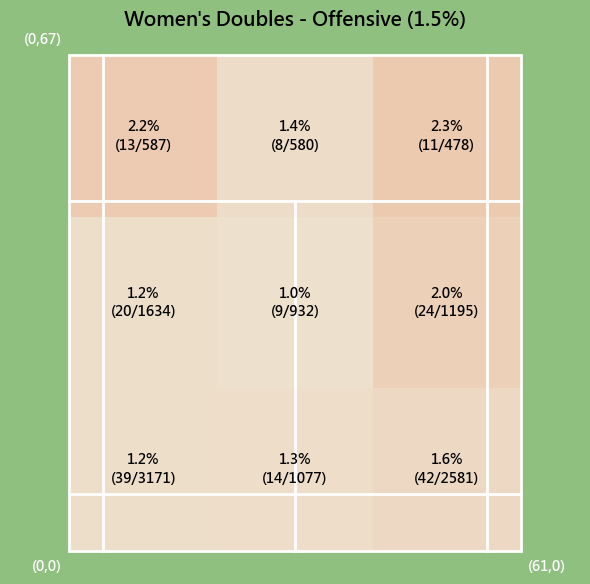

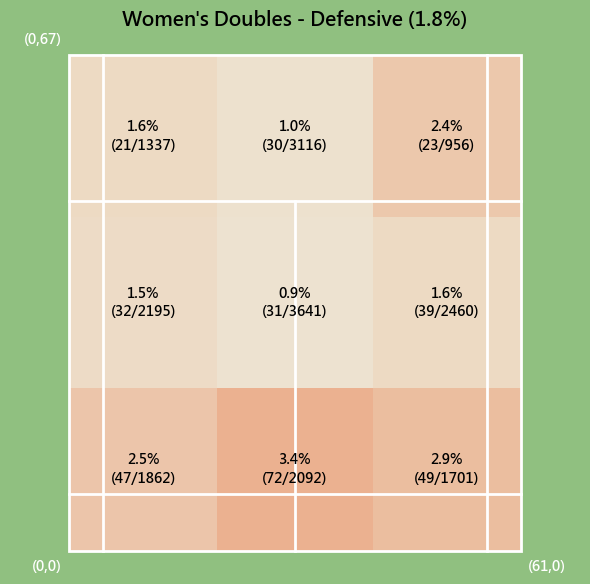

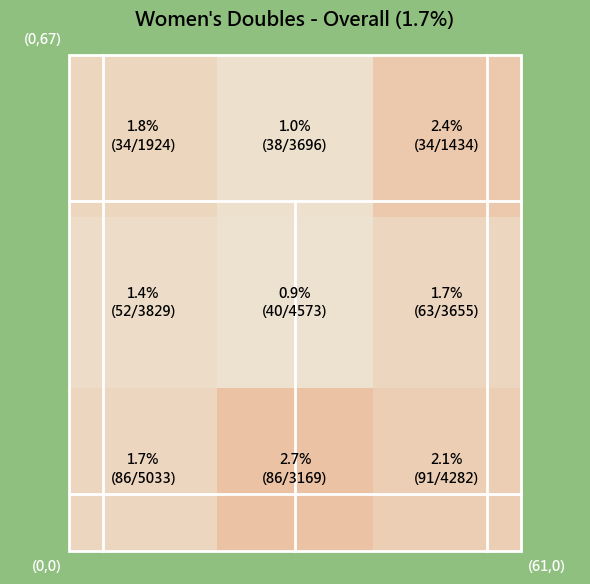

In [7]:
from src.analysis.defensive_failure import analyze_defensive_failure_rate
analyze_defensive_failure_rate(full_df, event_type=1)
analyze_defensive_failure_rate(full_df, event_type=2)

In [3]:
from src.analysis.matches_analyze import plot_badminton_intensity

match_tour_data = pd.merge(
        left=match_data,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )
plot_badminton_intensity(match_tour_data,df_match_rally_shot)

NameError: name 'match_data' is not defined

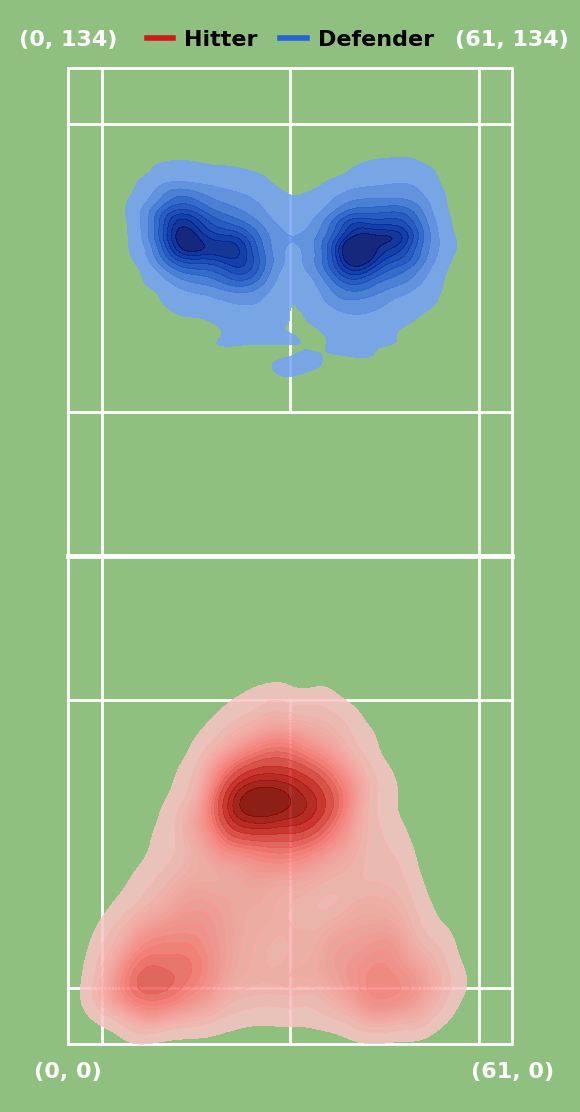

img/balltype/smash.png (400 DPI) successfully saved!


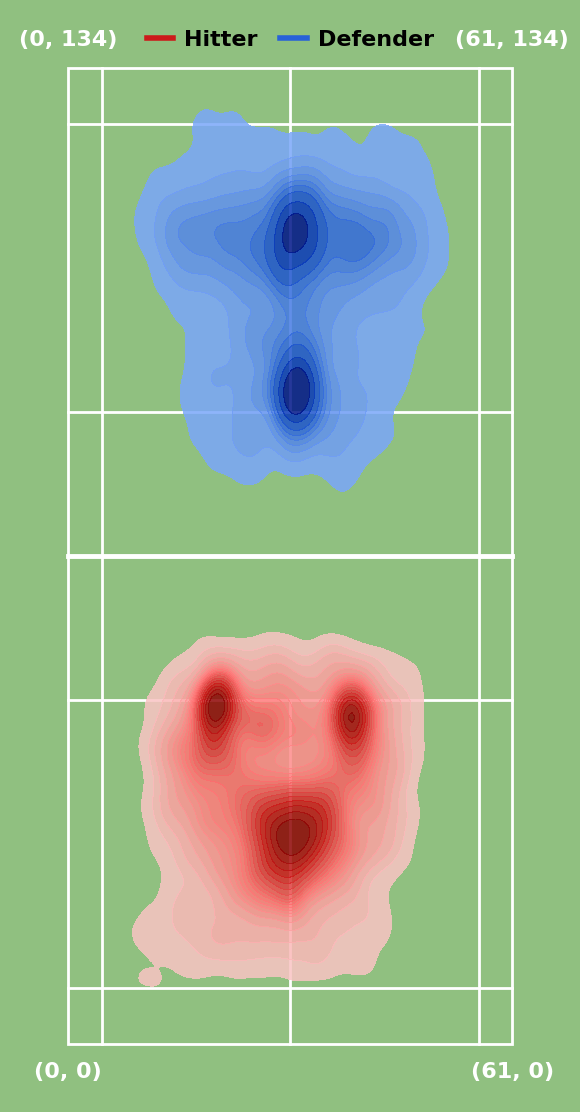

img/balltype/push.png (400 DPI) successfully saved!


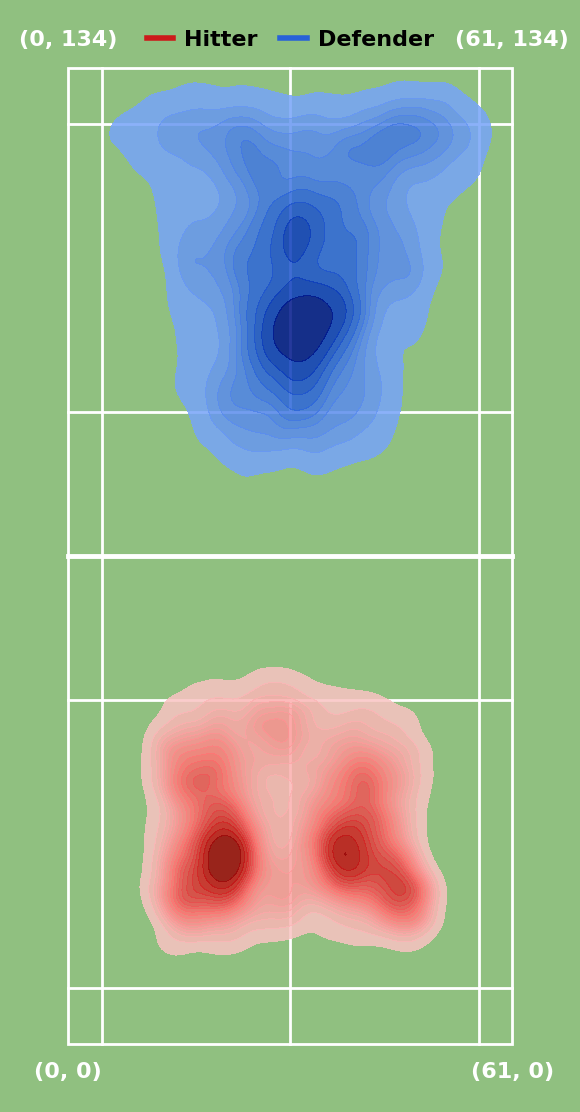

img/balltype/lift.png (400 DPI) successfully saved!


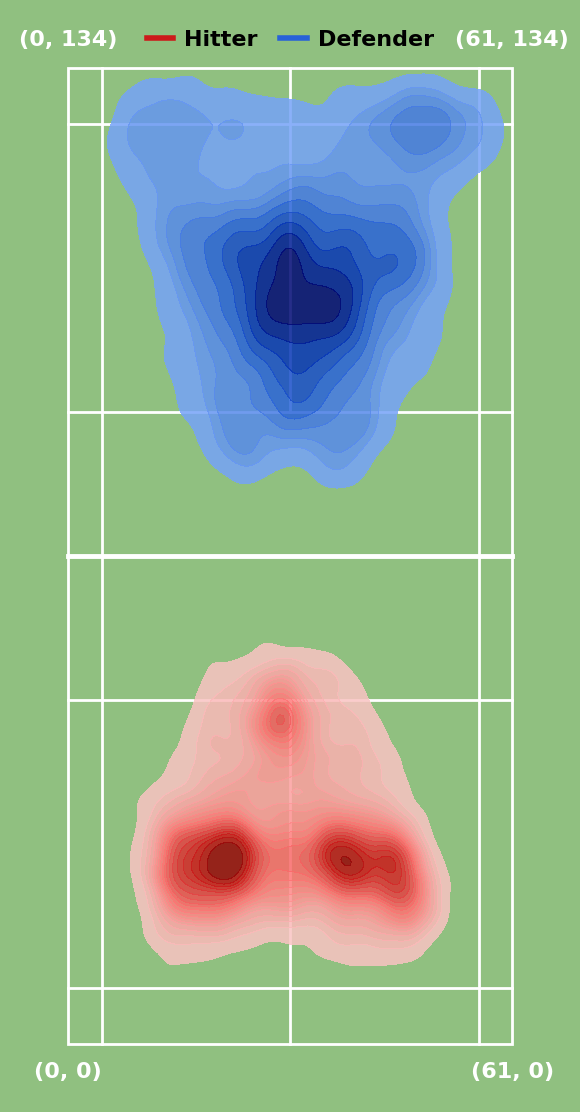

img/balltype/drive.png (400 DPI) successfully saved!


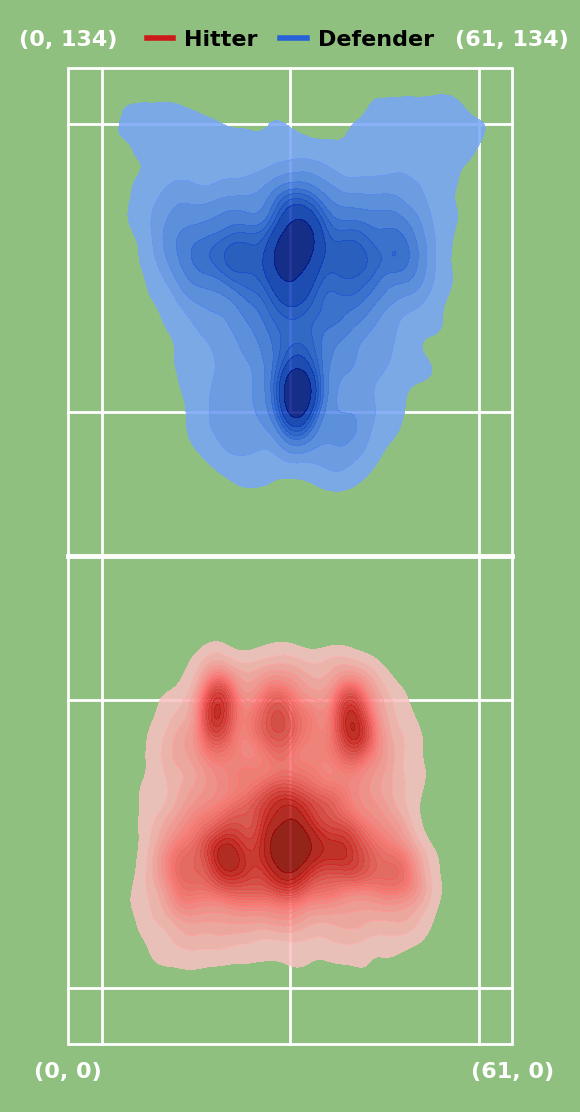

img/balltype/net shot.png (400 DPI) successfully saved!


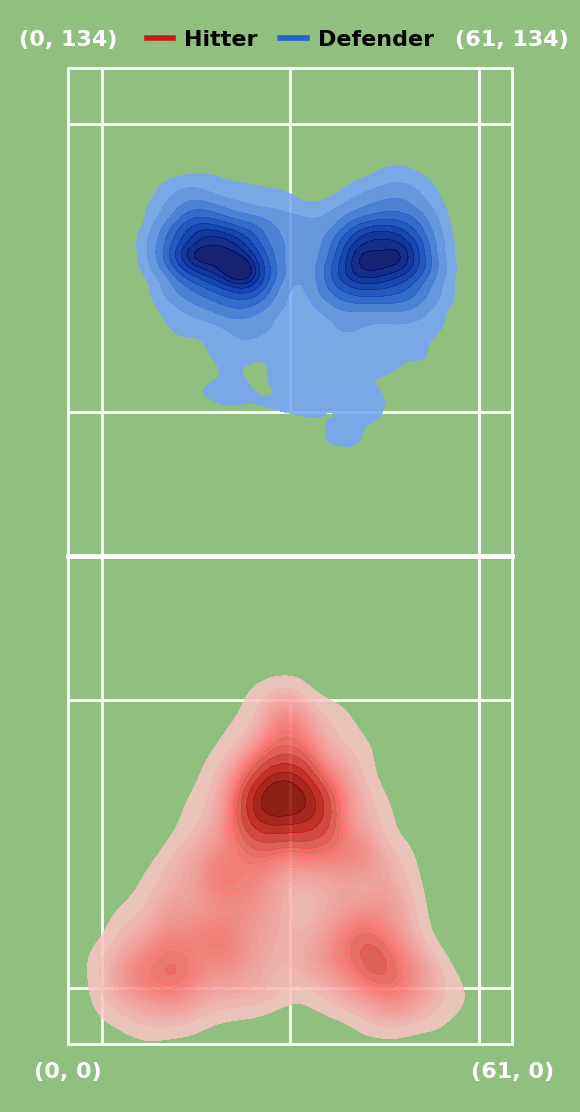

img/balltype/clear.png (400 DPI) successfully saved!


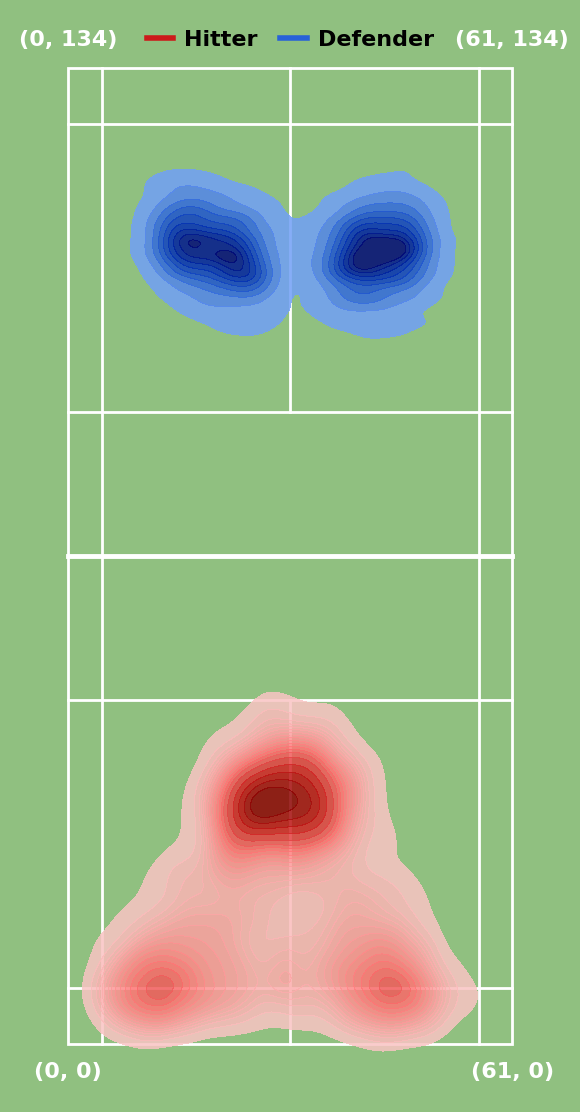

img/balltype/drop.png (400 DPI) successfully saved!


In [ ]:
from src.analysis.shottype_pos import prepare_occupancy_data, draw_attack_defense_map
balltype = ['smash','push','lift','drive','net shot','clear','drop']
no_serve_df = full_df[full_df['ball_type'] != 'short serve'].copy()
no_serve_df = no_serve_df[no_serve_df['ball_type'] != 'long serve'].copy()
for bt in balltype:
    df = no_serve_df[no_serve_df['ball_type'] == bt].copy()
    df = prepare_occupancy_data(df)
    draw_attack_defense_map(df,filename=f"img/shottype_pos/{bt}.png")

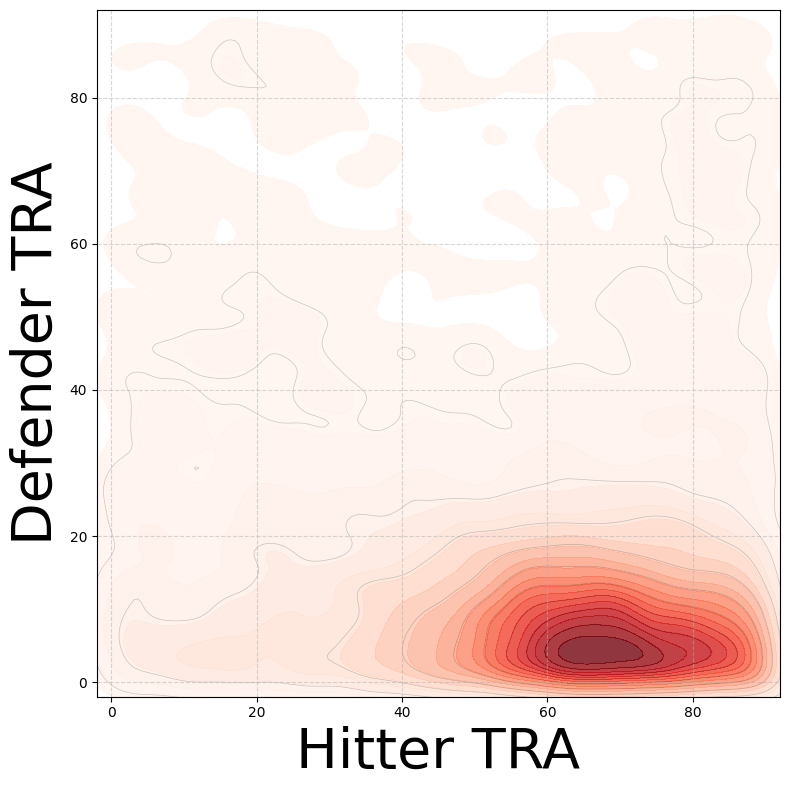

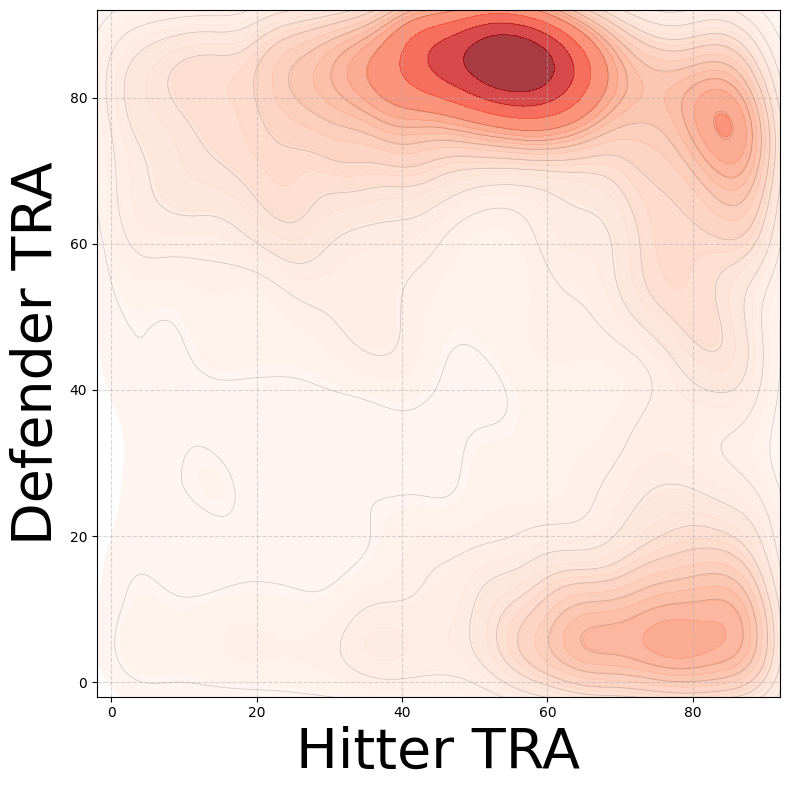

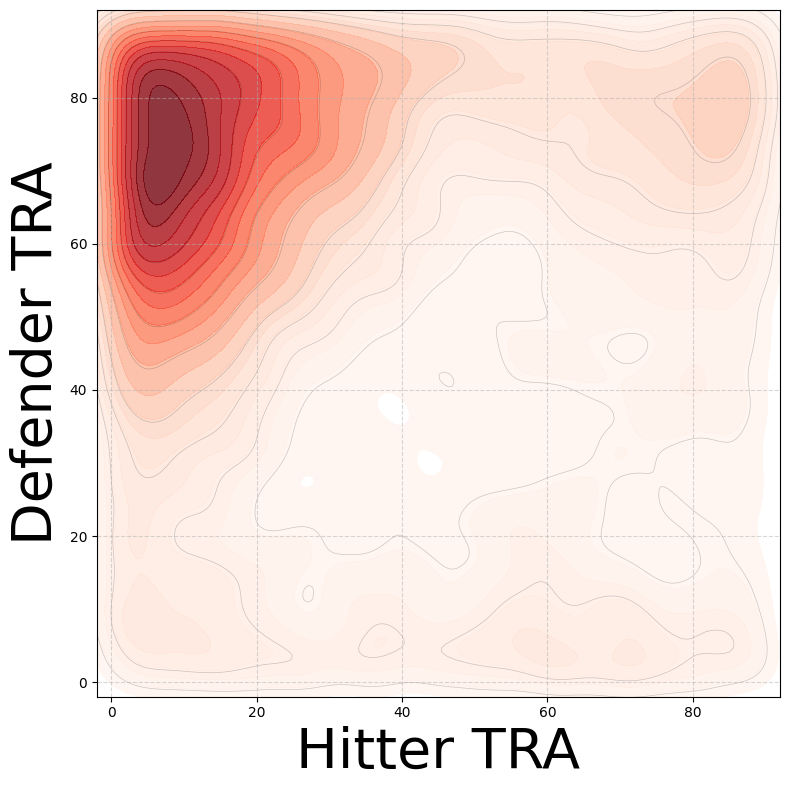

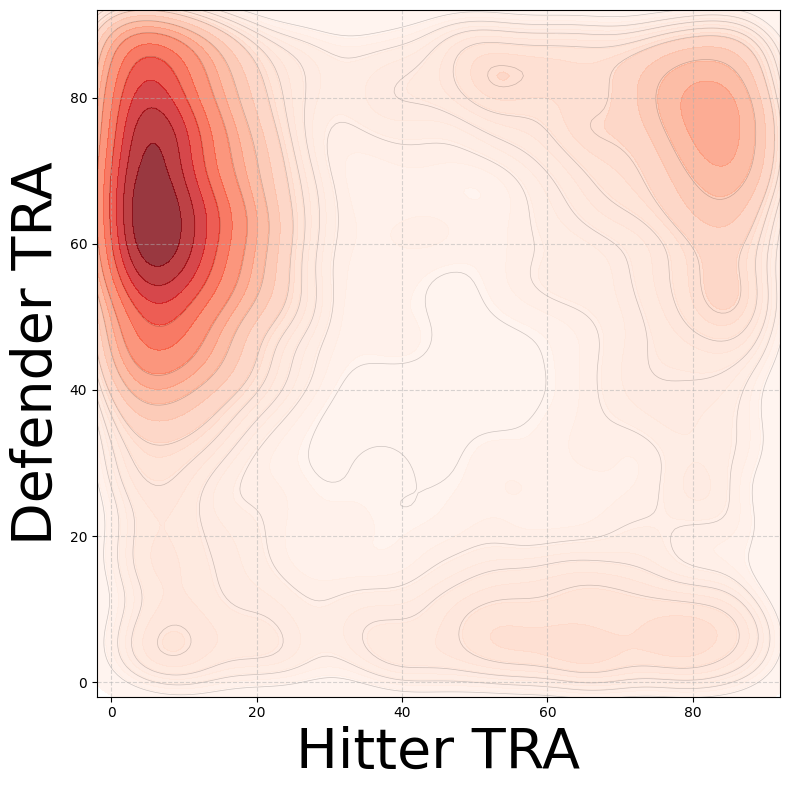

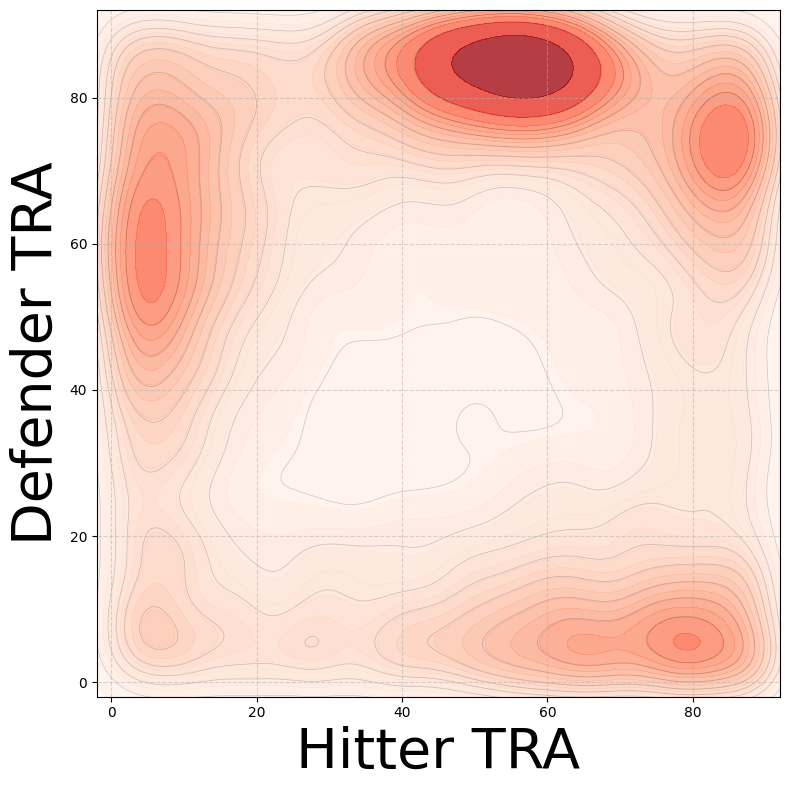

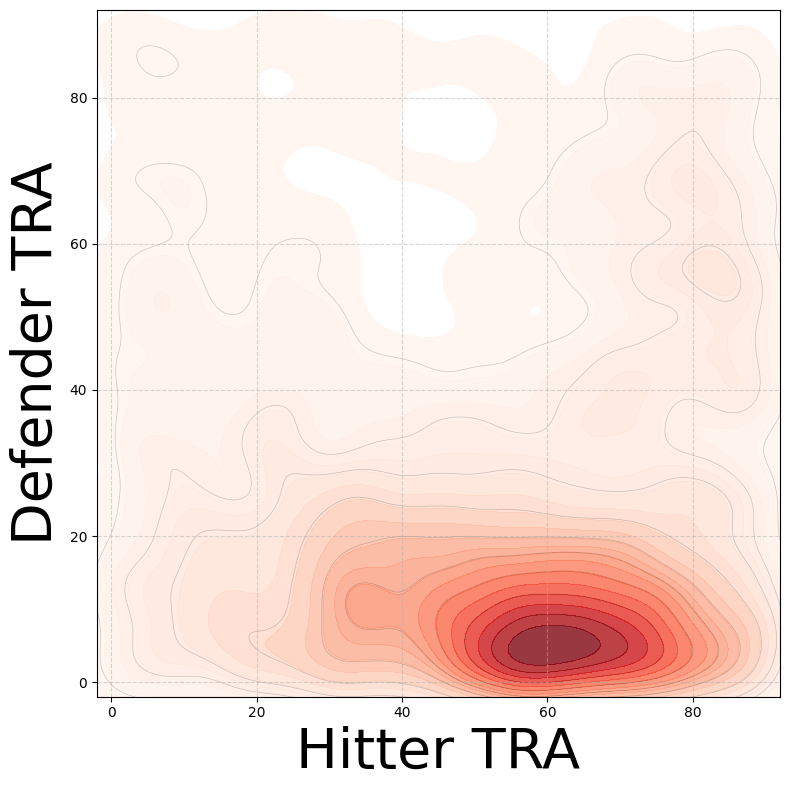

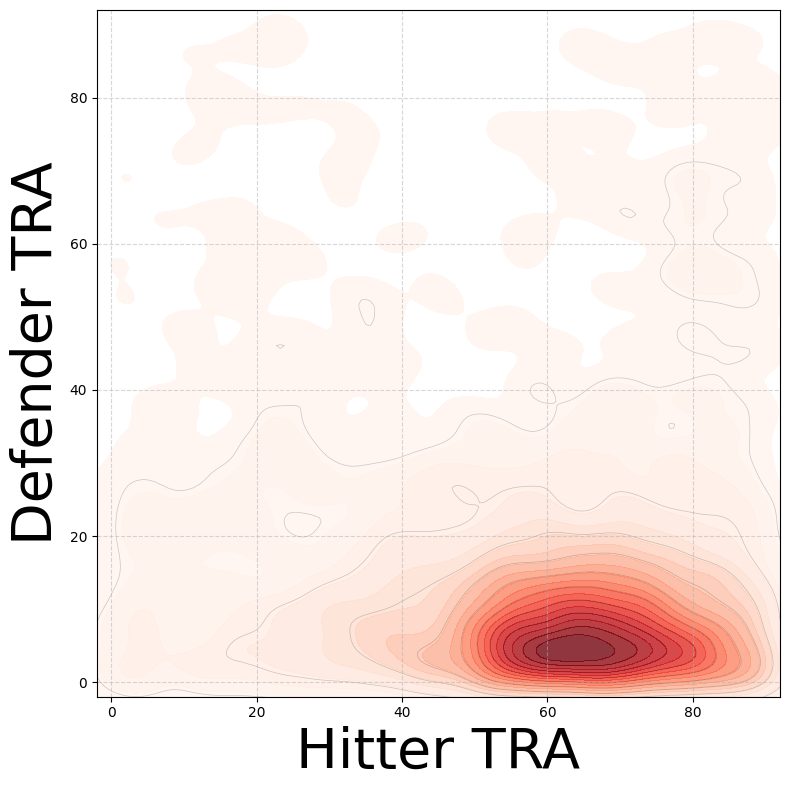

In [ ]:
from src.analysis.shottype_heatmap import normalize_halfcourt, plot_angle_relation_scatter
from src.analysis.shottype_pos import prepare_occupancy_data
balltype = ['smash','push','lift','drive','net shot','clear','drop']

for bt in balltype:
    df = no_serve_df[no_serve_df['ball_type'] == bt].copy()
    df = normalize_halfcourt(df)
    df = prepare_occupancy_data(df)
    plot_angle_relation_scatter(df, title="Attack and Defend",filename=f"img/shottype_heatmap/{bt}.png")